In [4]:
import os
import pandas as pd

os.chdir(r'C:\Users\pc\OneDrive\Desktop\ecommerce-analytics\notebooks')

DATA_PATH = r'C:\Users\pc\OneDrive\Desktop\ecommerce-analytics\data'

files = {
    'orders'     : 'olist_orders_dataset.csv',
    'items'      : 'olist_order_items_dataset.csv',
    'payments'   : 'olist_order_payments_dataset.csv',
    'reviews'    : 'olist_order_reviews_dataset.csv',
    'customers'  : 'olist_customers_dataset.csv',
    'products'   : 'olist_products_dataset.csv',
    'sellers'    : 'olist_sellers_dataset.csv',
    'category'   : 'product_category_name_translation.csv',       # ← fixed
    'geolocation': 'olist_geolocation_dataset.csv'                # ← bonus file
}

print("=" * 55)
print(f"{'Table':<15} {'Rows':>10} {'Columns':>10}")
print("=" * 55)

dfs = {}
for name, filename in files.items():
    path = os.path.join(DATA_PATH, filename)
    df   = pd.read_csv(path)
    dfs[name] = df
    print(f"{name:<15} {df.shape[0]:>10,} {df.shape[1]:>10}")

print("=" * 55)
print(f"\n✅ All 9 files loaded successfully")

Table                 Rows    Columns
orders              99,441          8
items              112,650          7
payments           103,886          5
reviews             99,224          7
customers           99,441          5
products            32,951          9
sellers              3,095          4
category                71          2
geolocation      1,000,163          5

✅ All 9 files loaded successfully


In [5]:
# Understand the schema — what joins what
print("=" * 60)
print("DATABASE SCHEMA & RELATIONSHIPS")
print("=" * 60)

for name, df in dfs.items():
    print(f"\n📋 {name.upper()}")
    print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"   Columns: {df.columns.tolist()}")

print("\n" + "=" * 60)
print("KEY RELATIONSHIPS")
print("=" * 60)
print("""
orders ──────────────── customers    (customer_id)
orders ──────────────── items        (order_id)
orders ──────────────── payments     (order_id)
orders ──────────────── reviews      (order_id)
items  ──────────────── products     (product_id)
items  ──────────────── sellers      (seller_id)
products ────────────── category     (product_category_name)
customers/sellers ────── geolocation (zip_code_prefix)
""")

DATABASE SCHEMA & RELATIONSHIPS

📋 ORDERS
   Shape: 99,441 rows × 8 columns
   Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

📋 ITEMS
   Shape: 112,650 rows × 7 columns
   Columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

📋 PAYMENTS
   Shape: 103,886 rows × 5 columns
   Columns: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

📋 REVIEWS
   Shape: 99,224 rows × 7 columns
   Columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

📋 CUSTOMERS
   Shape: 99,441 rows × 5 columns
   Columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

📋 PRODUCTS
   Shape: 32,951 rows × 9 columns
  

In [6]:
import pandas as pd
import numpy as np

print("=" * 60)
print("MISSING VALUES ACROSS ALL TABLES")
print("=" * 60)

for name, df in dfs.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"\n⚠️  {name.upper()}")
        for col, count in missing.items():
            pct = count / len(df) * 100
            print(f"   {col:<45} {count:>7,} ({pct:.1f}%)")
    else:
        print(f"\n✅ {name.upper()} — no missing values")

MISSING VALUES ACROSS ALL TABLES

⚠️  ORDERS
   order_approved_at                                 160 (0.2%)
   order_delivered_carrier_date                    1,783 (1.8%)
   order_delivered_customer_date                   2,965 (3.0%)

✅ ITEMS — no missing values

✅ PAYMENTS — no missing values

⚠️  REVIEWS
   review_comment_title                           87,656 (88.3%)
   review_comment_message                         58,247 (58.7%)

✅ CUSTOMERS — no missing values

⚠️  PRODUCTS
   product_category_name                             610 (1.9%)
   product_name_lenght                               610 (1.9%)
   product_description_lenght                        610 (1.9%)
   product_photos_qty                                610 (1.9%)
   product_weight_g                                    2 (0.0%)
   product_length_cm                                   2 (0.0%)
   product_height_cm                                   2 (0.0%)
   product_width_cm                                    2 (0.0%)


In [7]:
# Orders table has 6 date columns — convert all to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    dfs['orders'][col] = pd.to_datetime(dfs['orders'][col], errors='coerce')

# Add useful time columns
dfs['orders']['order_year']    = dfs['orders']['order_purchase_timestamp'].dt.year
dfs['orders']['order_month']   = dfs['orders']['order_purchase_timestamp'].dt.month
dfs['orders']['order_yearmon'] = dfs['orders']['order_purchase_timestamp'].dt.to_period('M').astype(str)
dfs['orders']['order_dow']     = dfs['orders']['order_purchase_timestamp'].dt.day_name()
dfs['orders']['order_hour']    = dfs['orders']['order_purchase_timestamp'].dt.hour

# Delivery time in days
dfs['orders']['delivery_days'] = (
    dfs['orders']['order_delivered_customer_date'] -
    dfs['orders']['order_purchase_timestamp']
).dt.days

# Delivery delay (positive = late, negative = early)
dfs['orders']['delivery_delay'] = (
    dfs['orders']['order_delivered_customer_date'] -
    dfs['orders']['order_estimated_delivery_date']
).dt.days

print("✅ Date columns converted")
print(f"\nOrder date range:")
print(f"  Earliest: {dfs['orders']['order_purchase_timestamp'].min()}")
print(f"  Latest:   {dfs['orders']['order_purchase_timestamp'].max()}")
print(f"\nDelivery time stats:")
print(dfs['orders']['delivery_days'].describe().round(1))

✅ Date columns converted

Order date range:
  Earliest: 2016-09-04 21:15:19
  Latest:   2018-10-17 17:30:18

Delivery time stats:
count    96476.0
mean        12.1
std          9.6
min          0.0
25%          6.0
50%         10.0
75%         15.0
max        209.0
Name: delivery_days, dtype: float64


In [8]:
# This is the single most important cell — joins all 8 tables into one
master = (
    dfs['orders']
    .merge(dfs['items'],    on='order_id',            how='left')
    .merge(dfs['payments']
           .groupby('order_id')
           .agg(payment_value=('payment_value','sum'),
                payment_type =('payment_type','first'))
           .reset_index(),                            on='order_id', how='left')
    .merge(dfs['reviews'][['order_id','review_score']],
                                                      on='order_id', how='left')
    .merge(dfs['customers'],  on='customer_id',       how='left')
    .merge(dfs['products'],   on='product_id',        how='left')
    .merge(dfs['sellers'],    on='seller_id',         how='left')
    .merge(dfs['category'],   on='product_category_name', how='left')
)

print(f"✅ Master table created")
print(f"   Shape: {master.shape[0]:,} rows × {master.shape[1]} columns")
print(f"\nColumns in master table:")
print(master.columns.tolist())
print(f"\nPreview:")
master.head(3)

✅ Master table created
   Shape: 114,092 rows × 40 columns

Columns in master table:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_year', 'order_month', 'order_yearmon', 'order_dow', 'order_hour', 'delivery_days', 'delivery_delay', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'payment_value', 'payment_type', 'review_score', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name_english']

Preview:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_year,order_month,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP,auto


In [9]:
print("=" * 55)
print("KEY BUSINESS METRICS")
print("=" * 55)

# Revenue metrics
total_revenue  = master['payment_value'].sum()
total_orders   = dfs['orders']['order_id'].nunique()
total_customers= dfs['customers']['customer_id'].nunique()
total_products = dfs['products']['product_id'].nunique()
total_sellers  = dfs['sellers']['seller_id'].nunique()
aov            = total_revenue / total_orders
avg_rating     = dfs['reviews']['review_score'].mean()
avg_delivery   = dfs['orders']['delivery_days'].mean()

print(f"  💰 Total Revenue:       R$ {total_revenue:>12,.2f}")
print(f"  📦 Total Orders:        {total_orders:>12,}")
print(f"  👥 Total Customers:     {total_customers:>12,}")
print(f"  🛍️  Unique Products:     {total_products:>12,}")
print(f"  🏪 Active Sellers:      {total_sellers:>12,}")
print(f"  💳 Avg Order Value:     R$ {aov:>12,.2f}")
print(f"  ⭐ Avg Review Score:    {avg_rating:>12.2f} / 5.0")
print(f"  🚚 Avg Delivery Days:   {avg_delivery:>12.1f} days")
print("=" * 55)

KEY BUSINESS METRICS
  💰 Total Revenue:       R$ 20,579,664.01
  📦 Total Orders:              99,441
  👥 Total Customers:           99,441
  🛍️  Unique Products:           32,951
  🏪 Active Sellers:             3,095
  💳 Avg Order Value:     R$       206.95
  ⭐ Avg Review Score:            4.09 / 5.0
  🚚 Avg Delivery Days:           12.1 days


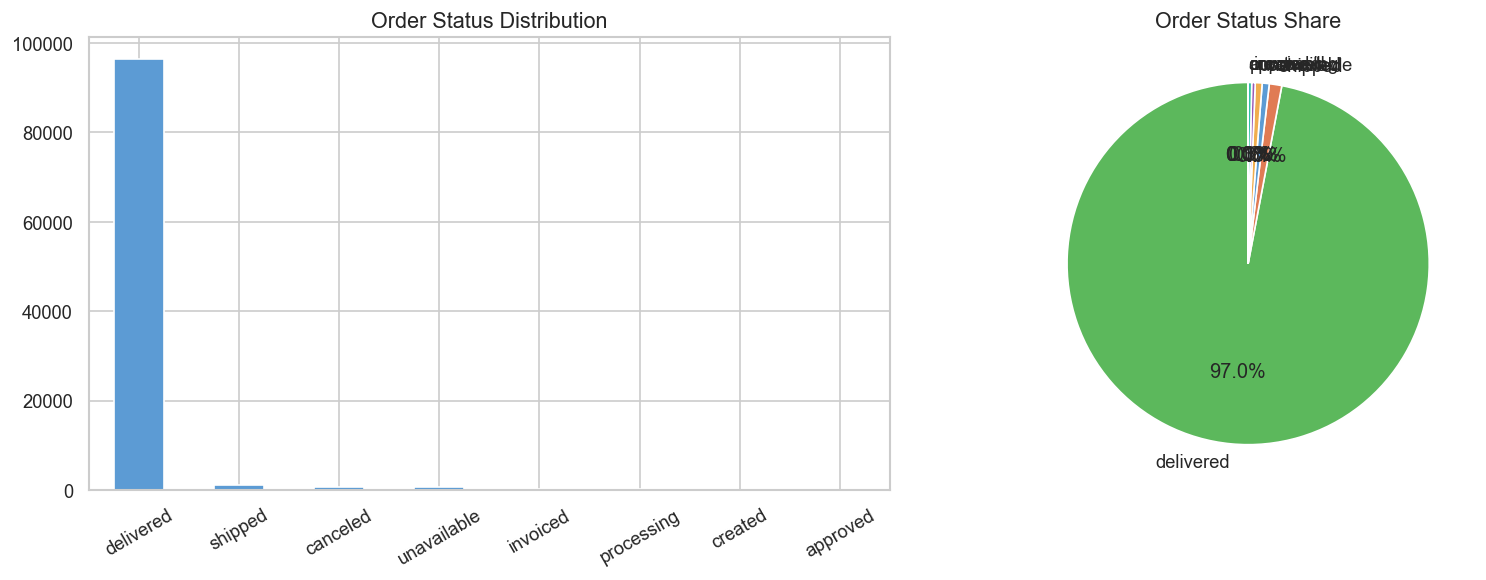


✅ 97.0% of orders were successfully delivered


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

status_counts = dfs['orders']['order_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
status_counts.plot(kind='bar', ax=axes[0],
                   color='#5C9BD4', edgecolor='white', rot=30)
axes[0].set_title('Order Status Distribution', fontsize=13)
axes[0].set_xlabel('')

# Focus on delivered only
delivered_pct = status_counts['delivered'] / status_counts.sum() * 100
axes[1].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#5CB85C','#E07B54','#5C9BD4','#F0AD4E','#9B59B6','#1ABC9C','#E74C3C','#95A5A6']
)
axes[1].set_title('Order Status Share', fontsize=13)

plt.tight_layout()
plt.savefig('../data/order_status.png')
plt.show()

print(f"\n✅ {delivered_pct:.1f}% of orders were successfully delivered")

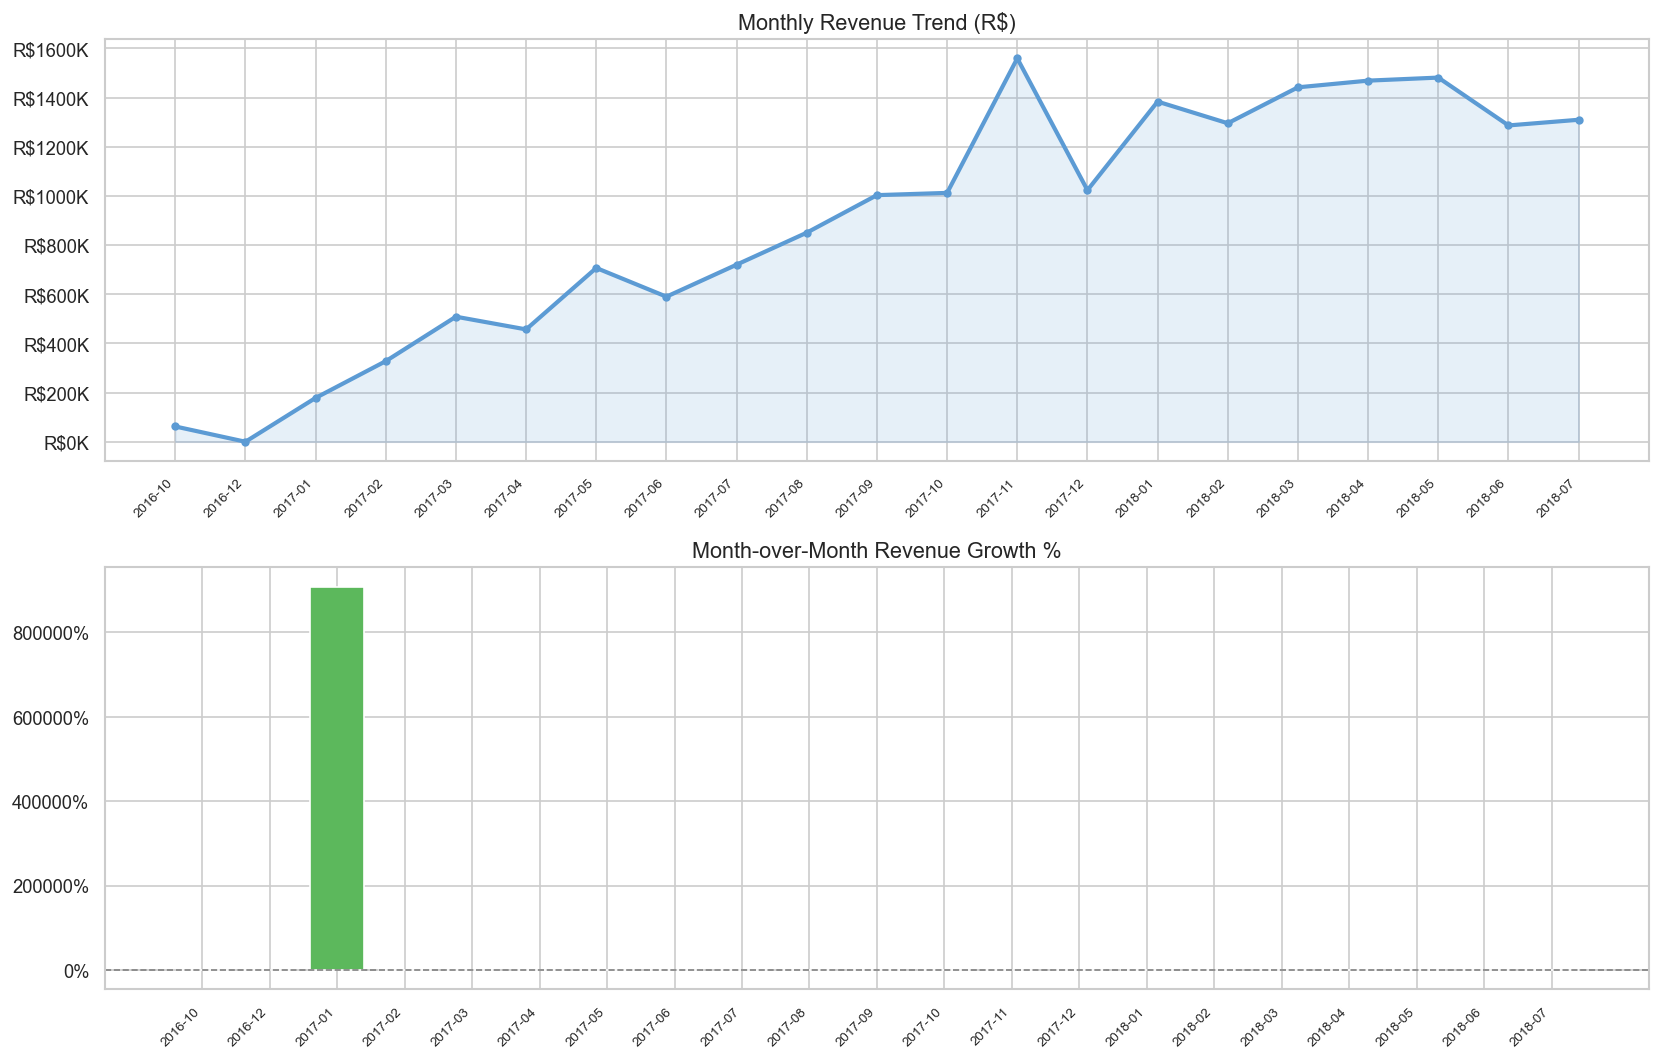


Peak revenue month: 2017-11
Peak revenue:       R$ 1,559,739.87
Best MoM growth:    908575.3%


In [11]:
monthly_revenue = (
    master[master['order_status'] == 'delivered']
    .groupby('order_yearmon')
    .agg(
        revenue      = ('payment_value', 'sum'),
        orders       = ('order_id',      'nunique'),
        avg_order_val= ('payment_value', 'mean')
    )
    .reset_index()
    .sort_values('order_yearmon')
)

# Remove incomplete months (first and last)
monthly_revenue = monthly_revenue.iloc[1:-1]

# Month over Month growth
monthly_revenue['mom_growth'] = monthly_revenue['revenue'].pct_change() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Revenue trend
axes[0].plot(monthly_revenue['order_yearmon'],
             monthly_revenue['revenue'],
             color='#5C9BD4', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(range(len(monthly_revenue)),
                     monthly_revenue['revenue'],
                     alpha=0.15, color='#5C9BD4')
axes[0].set_title('Monthly Revenue Trend (R$)', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_xticks(range(len(monthly_revenue)))
axes[0].set_xticklabels(monthly_revenue['order_yearmon'],
                         rotation=45, ha='right', fontsize=8)
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))

# MoM growth
colors = ['#5CB85C' if x >= 0 else '#E07B54'
          for x in monthly_revenue['mom_growth'].fillna(0)]
axes[1].bar(range(len(monthly_revenue)),
            monthly_revenue['mom_growth'].fillna(0),
            color=colors, edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=1, linestyle='--')
axes[1].set_title('Month-over-Month Revenue Growth %', fontsize=13)
axes[1].set_xticks(range(len(monthly_revenue)))
axes[1].set_xticklabels(monthly_revenue['order_yearmon'],
                         rotation=45, ha='right', fontsize=8)
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('../data/monthly_revenue.png')
plt.show()

print(f"\nPeak revenue month: {monthly_revenue.loc[monthly_revenue['revenue'].idxmax(), 'order_yearmon']}")
print(f"Peak revenue:       R$ {monthly_revenue['revenue'].max():,.2f}")
print(f"Best MoM growth:    {monthly_revenue['mom_growth'].max():.1f}%")

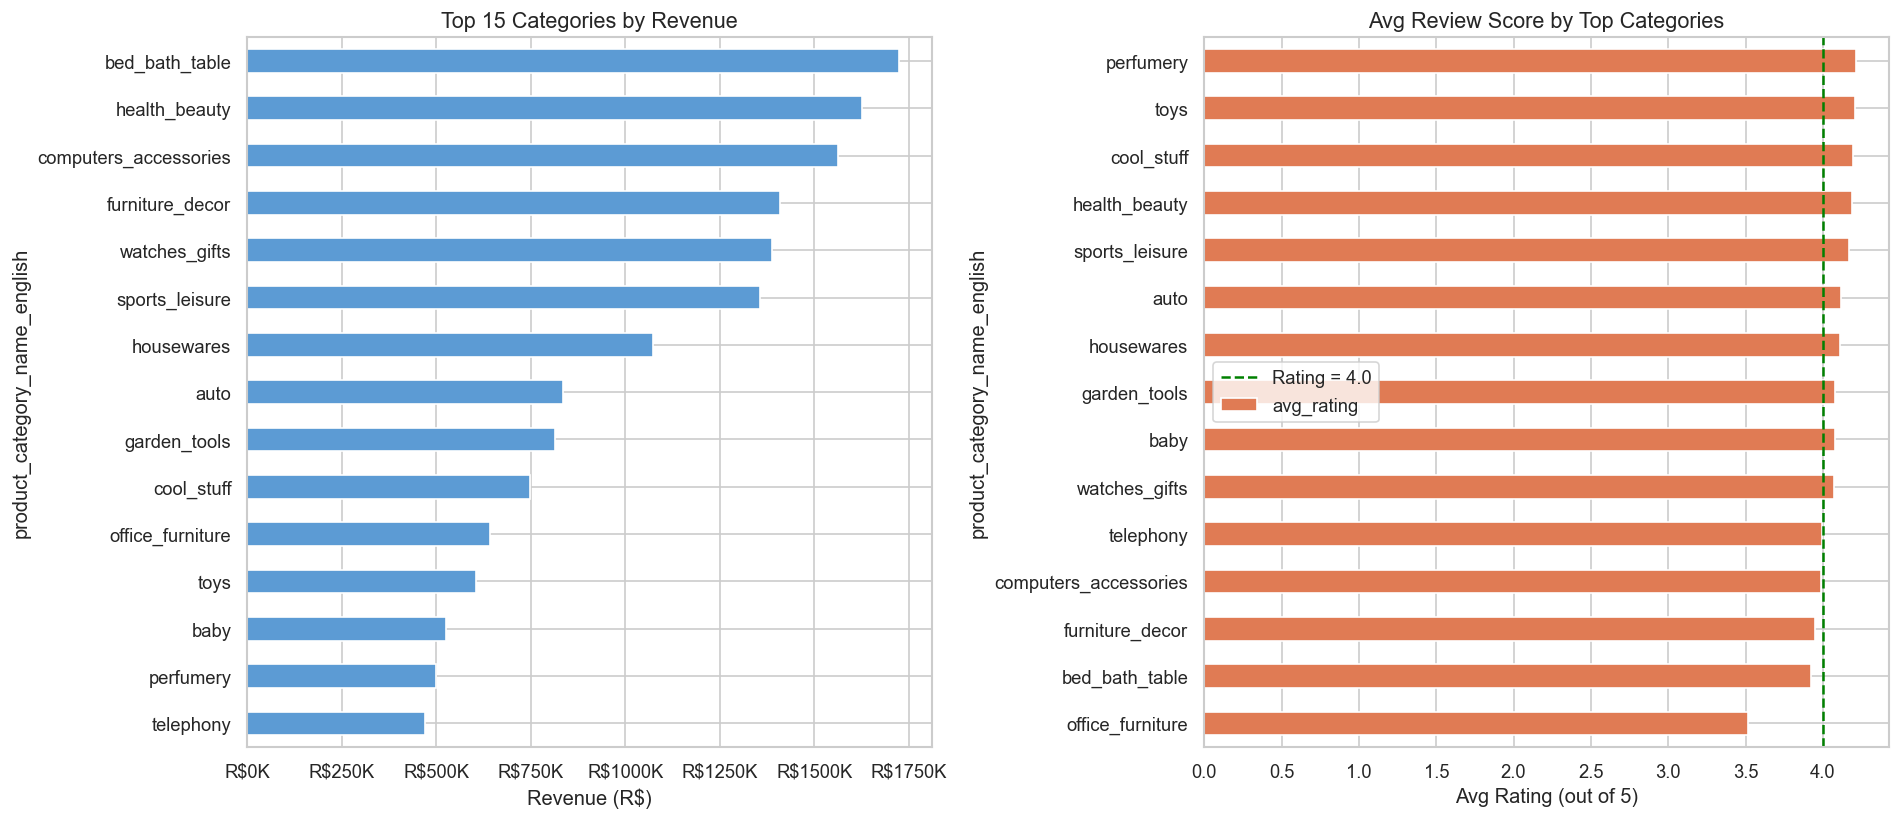

In [12]:
category_revenue = (
    master[master['order_status'] == 'delivered']
    .groupby('product_category_name_english')
    .agg(
        revenue      = ('payment_value', 'sum'),
        orders       = ('order_id',      'nunique'),
        avg_price    = ('price',         'mean'),
        avg_rating   = ('review_score',  'mean')
    )
    .reset_index()
    .sort_values('revenue', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 15 by revenue
category_revenue.sort_values('revenue').plot(
    kind='barh', x='product_category_name_english',
    y='revenue', ax=axes[0],
    color='#5C9BD4', edgecolor='white', legend=False
)
axes[0].set_title('Top 15 Categories by Revenue', fontsize=13)
axes[0].set_xlabel('Revenue (R$)')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))

# Avg rating by category
category_revenue.sort_values('avg_rating').plot(
    kind='barh', x='product_category_name_english',
    y='avg_rating', ax=axes[1],
    color='#E07B54', edgecolor='white', legend=False
)
axes[1].set_title('Avg Review Score by Top Categories', fontsize=13)
axes[1].set_xlabel('Avg Rating (out of 5)')
axes[1].axvline(4.0, color='green', linestyle='--', linewidth=1.5,
                label='Rating = 4.0')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/category_analysis.png')
plt.show()

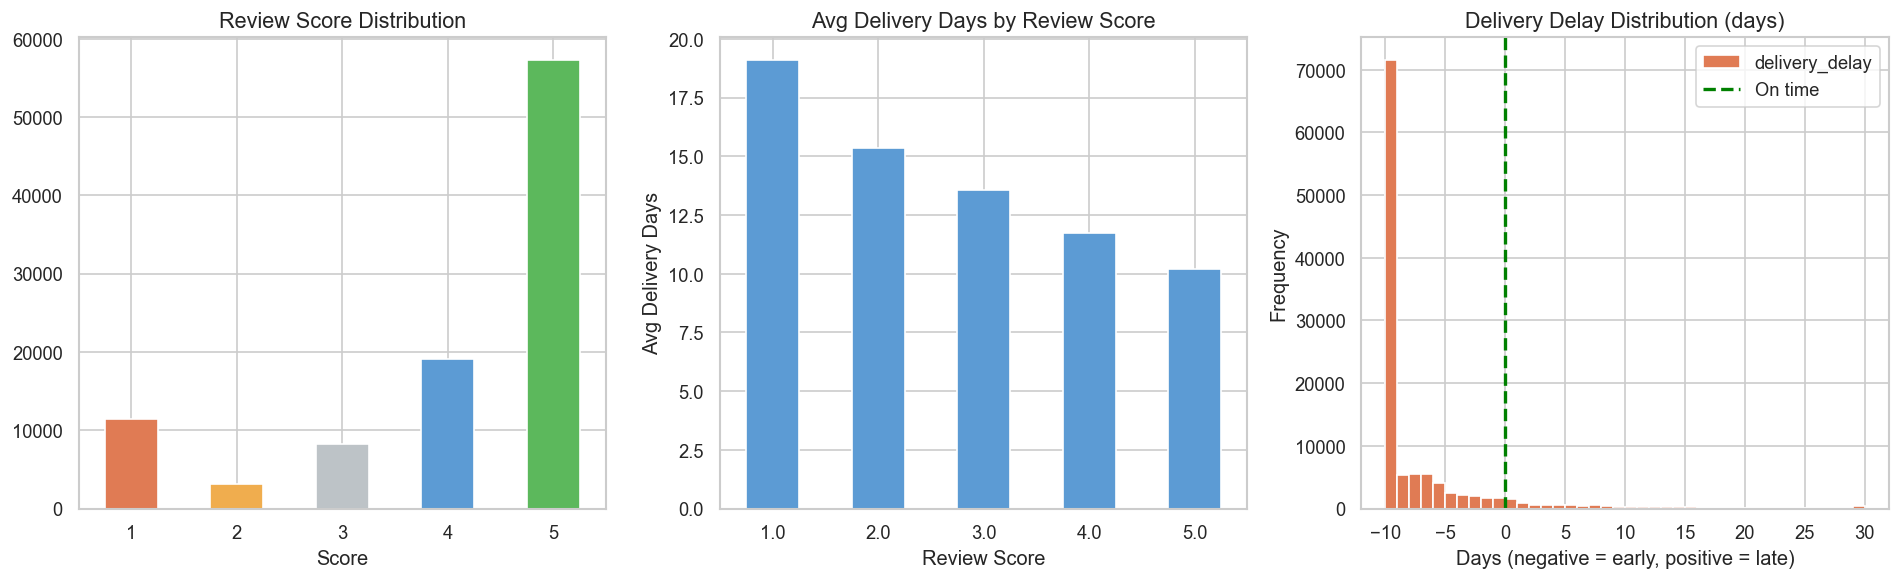


⚠️  Late deliveries: 7,294 (6.6% of orders)
✅ Early/on-time:    103,545 (93.4% of orders)


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Review score distribution
dfs['reviews']['review_score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    color=['#E07B54','#F0AD4E','#BDC3C7','#5C9BD4','#5CB85C'],
    edgecolor='white', rot=0
)
axes[0].set_title('Review Score Distribution', fontsize=13)
axes[0].set_xlabel('Score')

# Delivery days vs review score
master.groupby('review_score')['delivery_days'].mean().plot(
    kind='bar', ax=axes[1],
    color='#5C9BD4', edgecolor='white', rot=0
)
axes[1].set_title('Avg Delivery Days by Review Score', fontsize=13)
axes[1].set_xlabel('Review Score')
axes[1].set_ylabel('Avg Delivery Days')

# Delivery delay distribution
master['delivery_delay'].clip(-10, 30).dropna().plot(
    kind='hist', bins=40, ax=axes[2],
    color='#E07B54', edgecolor='white'
)
axes[2].axvline(0, color='green', linewidth=2,
                linestyle='--', label='On time')
axes[2].set_title('Delivery Delay Distribution (days)', fontsize=13)
axes[2].set_xlabel('Days (negative = early, positive = late)')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/reviews_delivery.png')
plt.show()

# Key insight
late_orders = (master['delivery_delay'] > 0).sum()
total       = master['delivery_delay'].notna().sum()
print(f"\n⚠️  Late deliveries: {late_orders:,} ({late_orders/total*100:.1f}% of orders)")
print(f"✅ Early/on-time:    {total-late_orders:,} ({(total-late_orders)/total*100:.1f}% of orders)")

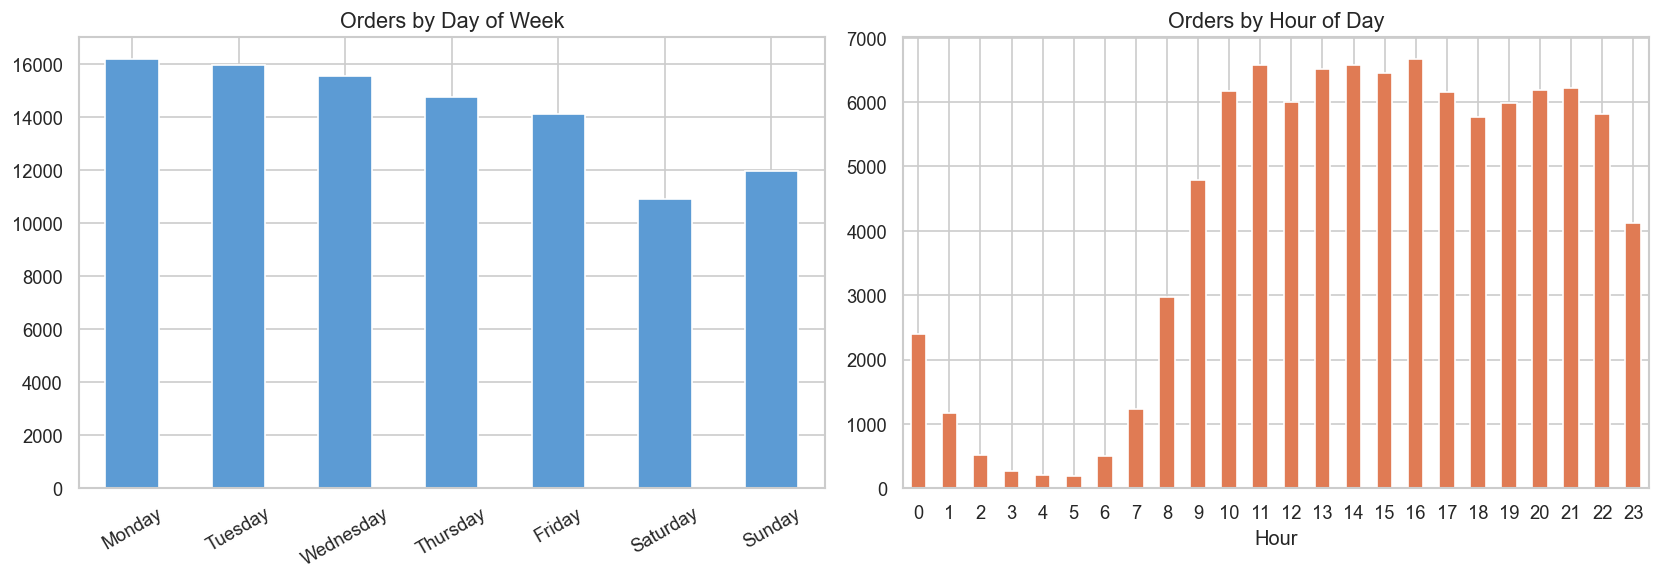


📅 Peak order day:  Monday
🕐 Peak order hour: 16:00


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week ordering
dow_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
dow_counts = (dfs['orders']['order_dow']
              .value_counts()
              .reindex(dow_order))

dow_counts.plot(kind='bar', ax=axes[0],
                color='#5C9BD4', edgecolor='white', rot=30)
axes[0].set_title('Orders by Day of Week', fontsize=13)
axes[0].set_xlabel('')

# Hour of day
dfs['orders']['order_hour'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1],
    color='#E07B54', edgecolor='white', rot=0
)
axes[1].set_title('Orders by Hour of Day', fontsize=13)
axes[1].set_xlabel('Hour')

plt.tight_layout()
plt.savefig('../data/orders_timing.png')
plt.show()

peak_hour = dfs['orders']['order_hour'].value_counts().idxmax()
peak_day  = dfs['orders']['order_dow'].value_counts().idxmax()
print(f"\n📅 Peak order day:  {peak_day}")
print(f"🕐 Peak order hour: {peak_hour}:00")

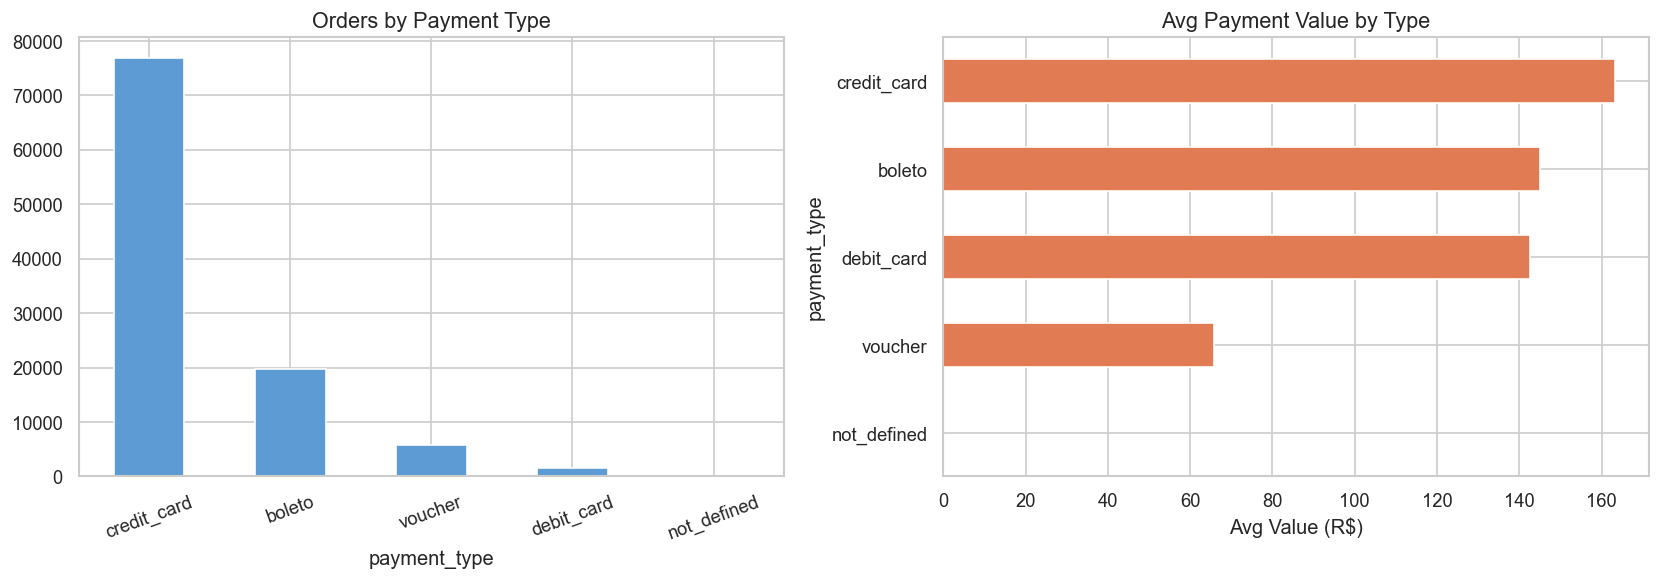


Payment type breakdown:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payment type distribution
pay_counts = dfs['payments']['payment_type'].value_counts()
pay_counts.plot(kind='bar', ax=axes[0],
                color='#5C9BD4', edgecolor='white', rot=20)
axes[0].set_title('Orders by Payment Type', fontsize=13)

# Avg order value by payment type
(dfs['payments']
 .groupby('payment_type')['payment_value']
 .mean()
 .sort_values(ascending=True)
 .plot(kind='barh', ax=axes[1],
       color='#E07B54', edgecolor='white'))
axes[1].set_title('Avg Payment Value by Type', fontsize=13)
axes[1].set_xlabel('Avg Value (R$)')

plt.tight_layout()
plt.savefig('../data/payment_analysis.png')
plt.show()

print("\nPayment type breakdown:")
print(pay_counts.to_string())

In [16]:
summary = f"""
EDA SUMMARY — OLIST E-COMMERCE
================================
Tables:          9 (99K orders, 100K customers, 33K products)
Date range:      Sep 2016 — Oct 2018 (2 years)
Total Revenue:   R$ {master['payment_value'].sum():,.0f}
Total Orders:    {dfs['orders']['order_id'].nunique():,}
Avg Order Value: R$ {master['payment_value'].mean():,.2f}
Avg Rating:      {dfs['reviews']['review_score'].mean():.2f} / 5.0
Avg Delivery:    {dfs['orders']['delivery_days'].mean():.1f} days

KEY FINDINGS:
1. {dfs['orders']['order_status'].value_counts(normalize=True)['delivered']*100:.1f}% of orders successfully delivered
2. Late deliveries strongly correlated with low review scores
3. Peak orders: {dfs['orders']['order_dow'].value_counts().idxmax()}s at {dfs['orders']['order_hour'].value_counts().idxmax()}:00
4. Credit card dominates payment ({dfs['payments']['payment_type'].value_counts(normalize=True).iloc[0]*100:.1f}% of orders)
5. bed_bath_table is the top revenue category

NEXT STEPS:
- Load into DuckDB
- Build dbt SQL pipeline
- RFM customer segmentation
- Market basket analysis
"""
print(summary)


EDA SUMMARY — OLIST E-COMMERCE
Tables:          9 (99K orders, 100K customers, 33K products)
Date range:      Sep 2016 — Oct 2018 (2 years)
Total Revenue:   R$ 20,579,664
Total Orders:    99,441
Avg Order Value: R$ 180.38
Avg Rating:      4.09 / 5.0
Avg Delivery:    12.1 days

KEY FINDINGS:
1. 97.0% of orders successfully delivered
2. Late deliveries strongly correlated with low review scores
3. Peak orders: Mondays at 16:00
4. Credit card dominates payment (73.9% of orders)
5. bed_bath_table is the top revenue category

NEXT STEPS:
- Load into DuckDB
- Build dbt SQL pipeline
- RFM customer segmentation
- Market basket analysis



In [17]:
import os

charts = [
    'order_status.png',
    'monthly_revenue.png', 
    'category_analysis.png',
    'reviews_delivery.png',
    'orders_timing.png',
    'payment_analysis.png'
]

print("Chart files:")
for chart in charts:
    path = f'../data/{chart}'
    exists = os.path.exists(path)
    print(f"  {'✅' if exists else '❌'} {chart}")

Chart files:
  ✅ order_status.png
  ✅ monthly_revenue.png
  ✅ category_analysis.png
  ✅ reviews_delivery.png
  ✅ orders_timing.png
  ✅ payment_analysis.png
